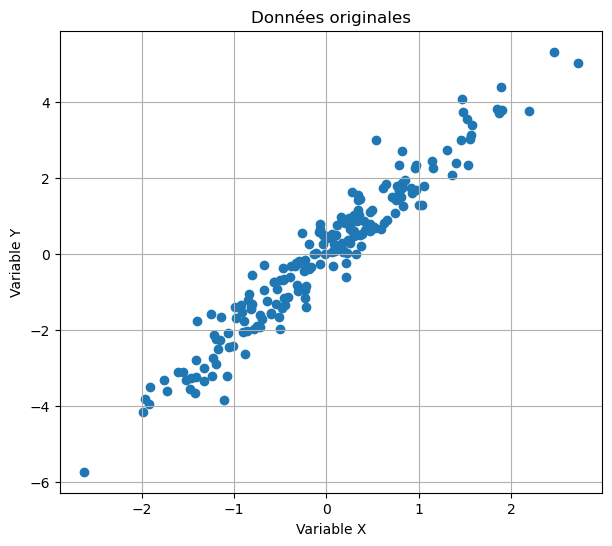

Matrice de covariance :
[[1.00502513 0.97331214]
 [0.97331214 1.00502513]]

Valeurs propres :
[1.97833727 0.03171298]

Vecteurs propres :
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Valeurs propres triées :
[1.97833727 0.03171298]

Composantes principales :
[[0.70710678]
 [0.70710678]]

Données après PCA :
[[ 0.84473169]
 [-0.05895912]
 [ 1.19868656]
 [ 2.48951714]
 [-0.54949831]
 [-0.47038426]
 [ 2.47582816]
 [ 1.27362959]
 [-0.55759541]
 [ 1.54105079]]

Variance expliquée :
[0.98422279 0.01577721]


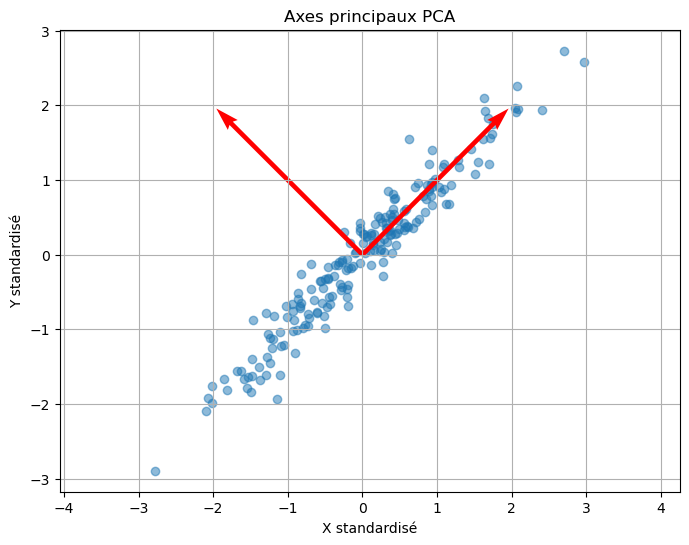

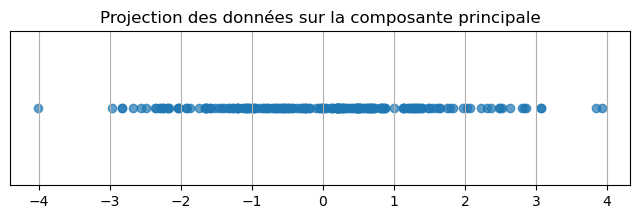

In [1]:
# ============================================================
#          PCA (Principal Component Analysis) FROM SCRATCH
# ============================================================
#
# PCA = Réduction de dimension
#
# But :
# Transformer des données avec plusieurs variables vers un espace plus petit tout en gardant le maximum d'information.
#
# Exemple :
# - 100 variables  --->  2 variables principales
#
# PCA cherche :
# Les directions où les données varient le plus.
#
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
#                 1. DONNÉES D'EXEMPLE
# ============================================================
#
# On crée des données 2D :
# X = taille
# Y = poids
#
# Les deux variables sont corrélées.
#
# PCA va trouver :
# - La direction principale de variation
# - Une nouvelle base de coordonnées
#
# ============================================================

np.random.seed(42)

# Génération des données
x = np.random.normal(0, 1, 200)

# y dépend de x
y = 2 * x + np.random.normal(0, 0.5, 200)

# Matrice des données
X = np.column_stack((x, y))


# ============================================================
#           AFFICHAGE DES DONNÉES ORIGINALES
# ============================================================

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1])

plt.title("Données originales")
plt.xlabel("Variable X")
plt.ylabel("Variable Y")

plt.grid(True)
plt.show()


# ============================================================
#                 2. STANDARDISATION
# ============================================================
#
# IMPORTANT :
# PCA est sensible aux échelles.
#
# Donc on standardise :
#
# z = (x - moyenne) / ecart_type
#
# ============================================================

# Moyenne de chaque colonne
mean = np.mean(X, axis=0)

# Écart type
std = np.std(X, axis=0)

# Standardisation
X_standardized = (X - mean) / std


# ============================================================
#            3. MATRICE DE COVARIANCE
# ============================================================
#
# La covariance mesure :
# comment deux variables varient ensemble.
#
# Formule :
#
#                1
# Cov(X,Y) = -------- Σ (Xi - X̄)(Yi - Ȳ)
#              n - 1
#
# Si covariance grande :
# les variables sont corrélées.
#
# ============================================================

cov_matrix = np.cov(X_standardized.T)

print("Matrice de covariance :")
print(cov_matrix)


# ============================================================
#            4. VALEURS PROPRES / VECTEURS PROPRES
# ============================================================
#
# PCA cherche :
#
# - Les directions importantes
# - Les axes maximisant la variance
#
# Cela se fait avec :
#
# Av = λv
#
# λ = valeur propre
# v = vecteur propre
#
# Les grands λ :
# => directions importantes
#
# ============================================================

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nValeurs propres :")
print(eigenvalues)

print("\nVecteurs propres :")
print(eigenvectors)


# ============================================================
#          5. TRI DES COMPOSANTES PRINCIPALES
# ============================================================
#
# On trie du plus important au moins important.
#
# La plus grande valeur propre :
# => composante principale principale (PC1)
#
# ============================================================

# Indices du tri décroissant
sorted_index = np.argsort(eigenvalues)[::-1]

# Tri des valeurs propres
sorted_eigenvalues = eigenvalues[sorted_index]

# Tri des vecteurs propres
sorted_eigenvectors = eigenvectors[:, sorted_index]

print("\nValeurs propres triées :")
print(sorted_eigenvalues)


# ============================================================
#            6. CHOIX DU NOMBRE DE COMPOSANTES
# ============================================================
#
# Ici :
# On garde seulement 1 composante principale.
#
# Donc :
# 2 dimensions ---> 1 dimension
#
# ============================================================

n_components = 1

principal_components = sorted_eigenvectors[:, :n_components]

print("\nComposantes principales :")
print(principal_components)


# ============================================================
#              7. PROJECTION DES DONNÉES
# ============================================================
#
# Projection :
#
# Z = XW
#
# X = données standardisées
# W = vecteurs propres
#
# Résultat :
# nouvelles coordonnées PCA
#
# ============================================================

X_pca = X_standardized.dot(principal_components)

print("\nDonnées après PCA :")
print(X_pca[:10])


# ============================================================
#           8. VARIANCE EXPLIQUÉE
# ============================================================
#
# Pourcentage d'information gardée.
#
# Formule :
#
# variance_expliquee = valeur_propre / somme_valeurs_propres
#
# ============================================================

explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

print("\nVariance expliquée :")
print(explained_variance)


# ============================================================
#            9. VISUALISATION DES AXES PCA
# ============================================================
#
# On affiche :
# - les données
# - les directions principales
#
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_standardized[:, 0],
    X_standardized[:, 1],
    alpha=0.5
)

# Origine
origin = [0, 0]

# Affichage des vecteurs propres
for i in range(len(sorted_eigenvalues)):

    vector = sorted_eigenvectors[:, i]

    plt.quiver(
        *origin,
        vector[0],
        vector[1],
        scale=3,
        color='red'
    )

plt.title("Axes principaux PCA")
plt.xlabel("X standardisé")
plt.ylabel("Y standardisé")

plt.grid(True)
plt.axis('equal')

plt.show()


# ============================================================
#        10. VISUALISATION APRÈS RÉDUCTION
# ============================================================
#
# Maintenant :
# les données sont compressées en 1D.
#
# ============================================================

plt.figure(figsize=(8, 2))

plt.scatter(
    X_pca[:, 0],
    np.zeros(len(X_pca)),
    alpha=0.7
)

plt.title("Projection des données sur la composante principale")

plt.yticks([])

plt.grid(True)

plt.show()